# LING 498 Hackathon — Prompt 5

## Hyphenated & clitic-like pieces (subtokens)

**Category:** Morphology / tokenization

**Question:** Do subtoken pieces (split on hyphens/apostrophes) show Zipf-like distributions? What does that say about “units”?

- **Data:** Brown tokens
- **Items to Count:** Pieces from `re.split(r"[-']", tok) for tokens containing - or '`.

**Steps**
- Select tokens with - or '.
- Split into parts; keep alphabetic parts.
- Run Zipf report/plot over parts.
- Interpret: function-like fragments vs lexical stems; tokenizer artifacts vs morphology.

**Deliverable:** Top-15 pieces + 4–5 sentence reflection on “unit choice.”

In [1]:
import re
from nltk.corpus import brown
from nltk import FreqDist

tokens = brown.words()

In [2]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Types: {len(ranked)} | Tokens: {sum(c for _,c in ranked)}")
    print("Top items:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [3]:
# Select tokens containing a hyphen (-) or apostrophe (')
compound_tokens = []

for token in tokens:
    if "-" in token or "'" in token:
        compound_tokens.append(token)

print(compound_tokens[:10])

["Atlanta's", "''", 'term-end', 'over-all', "''", 'September-October', "''", 'hard-fought', 'Mayor-nominate', "''"]


In [4]:
# Split into parts; keep alphabetic parts
subtokens = []

for token in compound_tokens:
    pieces = re.split(r"[-']", token)

    for piece in pieces:
        if piece.isalpha():
            subtokens.append(piece.lower())

print(subtokens[:10])

['atlanta', 's', 'term', 'end', 'over', 'all', 'september', 'october', 'hard', 'fought']



=== Brown corpus: Subtokens ===
Types: 5917 | Tokens: 35396
Top items:
 1. s                                        5903
 2. t                                        2115
 3. i                                        686
 4. don                                      490
 5. ll                                       442
 6. d                                        435
 7. didn                                     401
 8. you                                      348
 9. re                                       340
10. it                                       334
11. m                                        277
12. he                                       253
13. ve                                       245
14. one                                      212
15. self                                     211

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 1.396
 f1/(3*f3) = 2.868
 f1/(4*f4) = 3.012
 f1/(5*f5) = 2.671


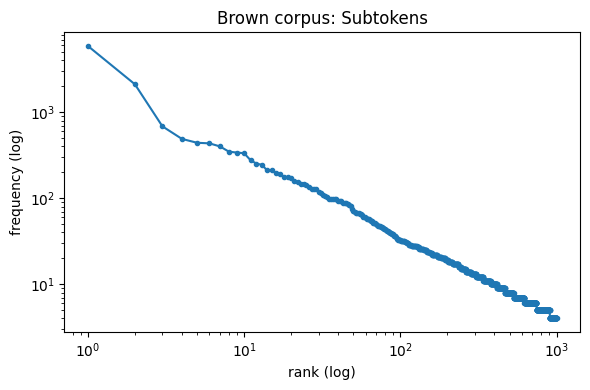

In [5]:
ranked = zipf_quick_report(subtokens, title="Brown corpus: Subtokens")
zipf_plot(ranked, title="Brown corpus: Subtokens")

### Interpretation

The distribution of subtokens follows a Zipf-like pattern, with a small number of subtokens occurring very frequently while most occur only a few times. Common subtokens such as `s`, `t`, and `i` appear many times because they are found in contractions, possessives, and hyphenated words throughout the corpus. For example, `s` appears in words such as *John's* or *it's*, `t` appears in contractions such as *don't* and *can't*, and `i` can appear in hyphenated words such as *Italian-American*. In this prompt, we counted subtokens created by splitting words at hyphens and apostrophes instead of counting whole words. If we had counted whole words, lemmas, or morphemes, the frequency distribution would have been different because each represents a different linguistic unit. This shows that the results of a Zipf analysis depend not only on the corpus but also on how the linguistic units are defined.